# Charting γ-secretase substrates by explainable AI

**Showcase a published study with AAanalysis.** Where a *tutorial* teaches one tool and
a *protocol* teaches one workflow, a **use case** walks through a real study end-to-end from
**bundled data only** (no downloads) — showing that a published result drops out of the
standard AAanalysis pipeline, and serving as a template you adapt to your own data.

This use case showcases [Breimann25]_:

   Breimann and Kamp *et al.* (2025), *Charting γ-secretase substrates by explainable
   AI*, [Nature Communications 16, 5428](https://www.nature.com/articles/s41467-025-60638-z).

**Biological motivation.** γ-secretase is an intramembrane-cleaving protease that cuts the
transmembrane domain of single-span membrane proteins, releasing fragments that drive
signalling — and it is central to Alzheimer's disease (it generates the amyloid-β peptide
from the amyloid precursor protein, APP) and to cancer (it activates Notch receptors). Yet
out of hundreds of single-span membrane proteins, γ-secretase cleaves only a subset, and
**no consensus sequence motif** marks which ones. Worse, the data is **weakly labelled**: a
few dozen expert-curated substrates, only a handful of confirmed non-substrates, and
hundreds of proteins of unknown status. The study asks what physicochemically defines a
substrate, and how to predict substrates despite this.

**The AAanalysis pipeline.** *Comparative Physicochemical Profiling* (**CPP**) builds an
interpretable, position-resolved **signature** of the substrates over a redundancy-reduced
set of amino-acid scales (curated with **AAclust**); *deterministic Positive-Unlabelled
learning* (**dPULearn**) mines **reliable negatives** from the unlabelled pool to balance
the data; a tree model predicts substrate status; and **SHAP** explains individual
predictions at single-residue resolution.

**What this showcases (key steps, simplified).** Sequence logos of the three protein
groups · an AAclust redundancy-reduced scale set · the CPP signature and feature map with
importances · dPULearn reliable-negative mining · a prediction benchmark (feature
engineering × data expansion) and feature-number optimization · single-residue SHAP
explanations for individual substrates.

**Simplifications (so it runs in seconds).** The study works over the full human N-out
proteome across ten model types with leave-one-out CV and three transmembrane annotations.
Here we use the bundled balanced ``DOM_GSEC`` set (63 substrates + 63 reliable
non-substrates) and the unlabelled ``DOM_GSEC_PU`` set (63 substrates + 631 others) with
their single embedded TMHMM annotation, one tree ensemble, and 5-fold cross-validation. The
biology and the headline numbers come through; scaling up is the *Protocols* (P1, P4, P7-P10).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict, LeaveOneOut, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

import aaanalysis as aa

aa.options["verbose"] = False
aa.options["random_state"] = 42
JMD_LEN = 10
sf = aa.SequenceFeature()

# Shared benchmark evaluator, as in the study: a linear support vector machine evaluated by
# leave-one-out cross-validation, scored by balanced accuracy. (probability=True is omitted -- it
# is unused for class predictions and deprecated in recent scikit-learn.)
def balanced_acc(X, y):
    y = np.asarray(y)
    y_pred = cross_val_predict(SVC(kernel="linear"), X, y, cv=LeaveOneOut(), n_jobs=-1)
    return balanced_accuracy_score(y, y_pred) * 100

## 1. Load the data

Two bundled **domain-level** (`DOM_`) datasets, one row per protein with the transmembrane
geometry and the pre-cut `jmd_n` / `tmd` / `jmd_c` parts:

- **`DOM_GSEC`** — the **curated** balanced set: 63 substrates (`label=1`) + 63 reliable
  non-substrates (`label=0`).
- **`DOM_GSEC_PU`** — the **positive-unlabelled** set: the same 63 substrates + 631
  *unlabelled* proteins of **unknown** status (`label=2`, the "others").

**TMD annotation.** The `jmd_n` / `tmd` / `jmd_c` split depends on where each protein's
**transmembrane domain (TMD)** sits in the sequence. That placement comes from a
**TMD-annotation prediction model** — a tool that predicts which residues span the membrane
(and hence the TMD boundaries that define the flanking juxtamembrane domains, JMD-N and
JMD-C) from the amino-acid sequence alone. The study combined **three** such annotations —
**UniProt**, **Phobius**, and **TMHMM** — to be robust to boundary disagreement between
predictors. Here we use only the **TMHMM** annotation for convenience; the biology and the
headline numbers still come through with this single source.

In [2]:
# 14 experimentally-known non-substrates retrieved from literature at the start of the study.
list_non_sub = ["P50895", "Q9Y624", "Q14802", "P05556", "P49257", "Q86UE4", "P16234",
                "Q969W9", "P53801", "Q8IUW5", "Q9NPR2", "P01135", "Q96JJ7", "O43914"]
_df_gsec = aa.load_dataset(name="DOM_GSEC")
_df_gsec_pu = aa.load_dataset(name="DOM_GSEC_PU")

# Split the raw data into the three biological groups of interest.
df_sub = _df_gsec[_df_gsec["label"] == 1]                     # curated substrates
df_non_sub = _df_gsec[_df_gsec["entry"].isin(list_non_sub)]   # curated non-substrates
df_unl = _df_gsec_pu[_df_gsec_pu["label"] == 2]               # unlabelled "others" (unknown status)

# Two working sets: CPP features come from substrates vs unlabelled (the raw signal); the ML
# benchmark is substrates vs the 14 experimentally-known non-substrates, exactly as in the study.
df_sub_nonsub = pd.concat([df_sub, df_non_sub]).reset_index(drop=True)  # 63 + 14 (benchmark)
df_sub_unl = pd.concat([df_sub, df_unl]).reset_index(drop=True)          # 63 + 631 (feature generation)
labels_sub_nonsub = (df_sub_nonsub["label"] == 1).astype(int).to_numpy() # 1 substrate, 0 non-substrate
labels_sub_unl = (df_sub_unl["label"] == 1).astype(int).to_numpy()       # 1 substrate, 0 unlabelled

print(f"Substrates: {len(df_sub)} | non-substrates: {len(df_non_sub)} | unlabelled: {len(df_unl)}")
print(f"Feature set (substrate vs unlabelled): {len(df_sub_unl)} | benchmark (substrate vs non-substrate): {len(df_sub_nonsub)}")
aa.display_df(df=df_sub_nonsub, n_rows=10, show_shape=True)

Substrates: 63 | non-substrates: 14 | unlabelled: 631
Feature set (substrate vs unlabelled): 694 | benchmark (substrate vs non-substrate): 77
DataFrame shape: (77, 8)


,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,P05067,MLPGLALLLLAAWTA...GYENPTYKFFEQMQN,1,701,723,FAEDVGSNKG,AIIGLMVGGVVIATVIVITLVML,KKKQYTSIHH
2,P14925,MAGRARSGLLLLLLG...EEEYSAPLPKPAPSS,1,868,890,KLSTEPGSGV,SVVLITTLLVIPVLVLLAIVMFI,RWKKSRAFGD
3,P70180,MRSLLLFTFSACVLL...RELREDSIRSHFSVA,1,477,499,PCKSSGGLEE,SAVTGIVVGALLGAGLLMAFYFF,RKKYRITIER
4,Q03157,MGPTSPAARGQGRRW...HGYENPTYRFLEERP,1,585,607,APSGTGVSRE,ALSGLLIMGAGGGSLIVLSLLLL,RKKKPYGTIS
5,Q06481,MAATGTAAAAATGRL...GYENPTYKYLEQMQI,1,694,716,LREDFSLSSS,ALIGLLVIAVAIATVIVISLVML,RKRQYGTISH
6,P35613,MAAALFVLLGFALLG...HQNDKGKNVRQRNSS,1,323,345,IITLRVRSHL,AALWPFLGIVAEVLVLVTIIFIY,EKRRKPEDVL
7,P35070,MDRAARCSGASSLPL...DITPINEDIEETNIA,1,119,141,LFYLRGDRGQ,ILVICLIAVMVVFIILVIGVCTC,CHPLRKRRKR
8,P09803,MGARCRSFSALLLLL...RFKKLADMYGGGEDD,1,711,733,GIVAAGLQVP,AILGILGGILALLILILLLLLFL,RRRTVVKEPL
9,P19022,MCRIAGALRTLLPLL...PRFKKLADMYGGGDD,1,724,746,RIVGAGLGTG,AIIAILLCIIILLILVLMFVVWM,KRRDKERQAK
10,P16070,MDKFWWHAAWGLCLV...DETRNLQNVDMKIGV,1,650,672,GPIRTPQIPE,WLIILASLLALALILAVCIAVNS,RRRCGQKKKL


## 2. Sequence logos of the three groups

For each group (substrates, non-substrates, unlabelled others) we draw one **sequence logo
with an information (bits) bar on top**. Passing `list_aal_kws` lets
`AAlogoPlot.multi_logo` build every logo directly from `df_parts` (each group selected by its
`label_test`) — so there is **no manual `AAlogo` step** — and, because the logo data is
computed internally, it also adds the per-position bits bar. If a simple consensus motif
marked substrates, it would jump out here.

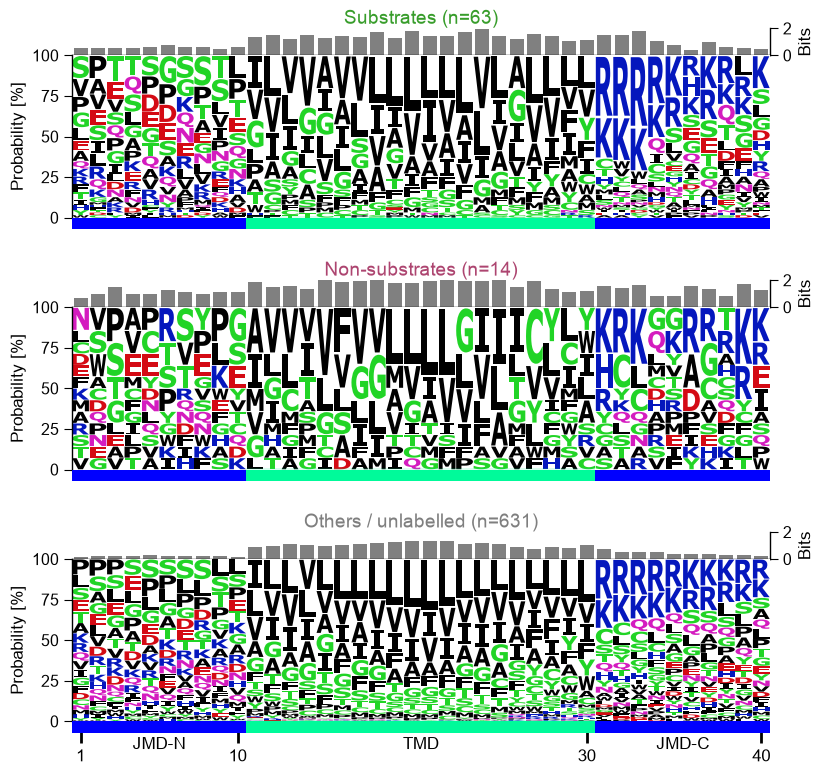

In [3]:
# Merged three-group frame for the sequence logos.
df_merged = pd.concat([df_sub.assign(label=1), df_non_sub.assign(label=0), df_unl.assign(label=2)], ignore_index=True)
labels = df_merged["label"].to_numpy()
y_dom = _df_gsec["label"].to_numpy()
y_pu = _df_gsec_pu["label"].to_numpy()

df_parts_merged = sf.get_df_parts(df_seq=df_merged, list_parts=["jmd_n", "tmd", "jmd_c"], 
                                  jmd_n_len=JMD_LEN, jmd_c_len=JMD_LEN)
# Get dataset colors 
dict_color = aa.plot_get_cdict(name="DICT_COLOR")
COLOR_SUB = dict_color["SAMPLES_POS"]
COLOR_NONSUB = dict_color["SAMPLES_NEG"]
COLOR_OTH = dict_color["SAMPLES_UNL"]
COLOR_REL_NONSUB = dict_color["SAMPLES_REL_NEG"]    

# Only the last 20 residues of the TMD are shown together with the last 5 of the JMD-N and the first 5 of the JMD-C.
# start_n=False aligns the logos at the END of the TMD (the most conserved, cleavage-proximal region).
args_logo = dict(df_parts=df_parts_merged, labels=labels, tmd_len=20, start_n=False)

# Compare three datasets by amino acid logos
aa.plot_settings(font_scale=0.7)
aal_plot = aa.AAlogoPlot(logo_type="probability", jmd_n_len=JMD_LEN, jmd_c_len=JMD_LEN)
fig, axes = aal_plot.multi_logo(
    list_aal_kws=[dict(**args_logo, label_test=1),
                  dict(**args_logo, label_test=0),
                  dict(**args_logo, label_test=2),
    ],
    list_name_data=["Substrates (n=63)", "Non-substrates (n=14)", "Others / unlabelled (n=631)"],
    list_name_data_color=[COLOR_SUB, COLOR_NONSUB, COLOR_OTH],
    figsize_per_logo=(9, 3),
    info_bar_ylim=(0, 2)
)
plt.tight_layout()
plt.show()

The three information (bits) logos share the same broad architecture: a hydrophobic,
low-information transmembrane core flanked by a lysine/arginine-enriched JMD-C. They are **not
identical** — the substrates carry slightly more information (more conserved positions) in the
C-terminal TMD and cleavage region than the unlabelled others, and the small non-substrate set
(n=14) is noisier — but there is **no single consensus motif** that cleanly marks substrates.
The discriminating signal is *physicochemical and position-dependent*, spread across many
positions, which is exactly what CPP is built to read.

## 3. AAclust: redundancy-reduced scale sets with full subcategory coverage

CPP describes each position by amino-acid **scales** (physicochemical property indices). The
bundled set has **586** scales, but many are near-duplicates. **AAclust** clusters them
(agglomerative, complete-linkage, as in the study) and keeps one representative **medoid** per
cluster. To avoid dropping whole property groups, :meth:`AAclust.filter_coverage` keeps raising
the cluster count until the medoids reach **100% subcategory coverage** -- i.e. every
subcategory still present in the input keeps at least one representative scale.

Following the study we build five scale sets of increasing curation
(**586 -> 232 -> 192 -> 161 -> 133** scales): all scales; 100%-coverage reductions over all and
over the classified scales; and two manually curated subcategory subsets (Supplementary Data 7).

In [4]:
aac = aa.AAclust(model_class=AgglomerativeClustering, model_kwargs={"linkage": "complete"})

df_scales = aa.load_scales(unclassified_out=False)                          # 20 AA x 586 scales (all)
df_scales_clf = aa.load_scales(unclassified_out=True) # 20 AA x 532 classified scales
df_cat = aa.load_scales(name="scales_cat")            # category table for all 586 scales

# 100% subcategory coverage. AAclust.filter_coverage clusters the scales (rows of X, so we
# transpose) and keeps one representative (medoid) per cluster, raising the cluster count until
# every subcategory present in the input has a representative (min_coverage=100). Returns scale ids.
def filter_100(df):
    scale_ids = list(df.columns)
    names_ref = df_cat[df_cat["scale_id"].isin(scale_ids)]["subcategory"].to_list()
    return aac.filter_coverage(X=df.T, scale_ids=scale_ids, names_ref=names_ref,
                               min_coverage=100, df_cat=df_cat, col_name="subcategory")

# Sets 4 and 5 keep only the more interpretable subcategories of the study (Supplementary Data 7),
# expressed as exclusions from the classified scales: set 4 drops the whole Composition category
# plus a few hard-to-interpret subcategories; set 5 additionally drops some structural ones.
# AAclust.pre_select_scales does the category / subcategory exclusion in one call.
list_subcat_remove_4 = ["β-turn", "β-turn (C-term)", "β-turn (N-term)", "Hydrophilicity"]
list_subcat_remove_5 = list_subcat_remove_4 + [
    "Linker (>14 AA)", "Linker (6-14 AA)", "α-helix (N-cap)", "α-helix (N-term)",
    "α-helix (N-term, out)", "α-helix (α-proteins)", "Free energy (folding)",
    "Hydrophobicity (surrounding)", "Graph (1. eigenvalue)", "Graph (2. eigenvalue)"]

def interpretable(subcat_out):
    return aac.pre_select_scales(df_scales_clf, df_cat=df_cat,
                                 cat_out=["Composition"], subcat_out=subcat_out)

scale_set1 = list(df_scales)                                   # set 1: all 586 scales, no reduction
scale_set2 = filter_100(df_scales)                             # set 2: all scales, 100% coverage
scale_set3 = filter_100(df_scales_clf)                         # set 3: classified scales, 100% coverage
scale_set4 = filter_100(interpretable(list_subcat_remove_4))   # set 4: interpretable subcats (broad)
scale_set5 = filter_100(interpretable(list_subcat_remove_5))   # set 5: interpretable subcats (core)

def n_subcat(scale_ids):
    return df_cat[df_cat["scale_id"].isin(scale_ids)]["subcategory"].nunique()
for i, scale_set in enumerate([scale_set1, scale_set2, scale_set3, scale_set4, scale_set5], start=1):
    print(f"Set {i}: {len(scale_set):>3} scales, {n_subcat(scale_set):>2} subcategories")

Set 1: 586 scales, 74 subcategories
Set 2: 232 scales, 74 subcategories
Set 3: 192 scales, 61 subcategories
Set 4: 161 scales, 52 subcategories
Set 5: 133 scales, 42 subcategories


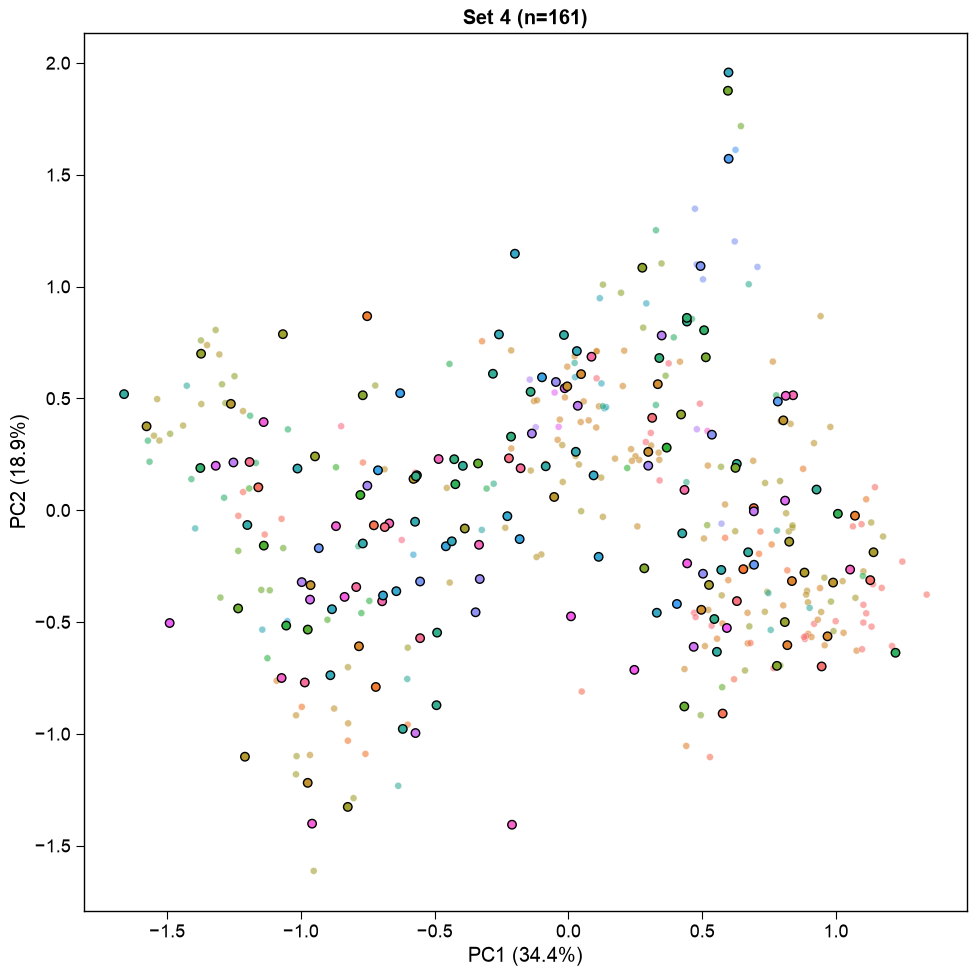

In [5]:
# Set 4 scale clustering as a single PCA medoids plot (one representative scale per cluster).
df_scales_set4 = interpretable(list_subcat_remove_4)
aa.plot_settings(font_scale=0.8)
cluster_labels = aac.fit(df_scales_set4.T, n_clusters=len(scale_set4)).labels_
aa.AAclustPlot().medoids(df_scales=df_scales_set4, labels=cluster_labels,
                         legend=False, dot_size=25, dot_alpha=0.6, figsize=(10, 10))
plt.title("Set 4 (n=161)", weight="bold")
plt.tight_layout()
plt.show()

## 4. Optimization: choosing the CPP feature space

CPP turns each protein into ``Part-Split-Scale`` features. We choose the feature space -- which
**sequence parts** and which **scale set** -- by benchmarking, exactly as in the study: CPP
features are generated from the **substrates vs unlabelled** contrast (``df_sub_unl``), and each
configuration is scored on the **substrates vs the 14 experimentally-known non-substrates**
benchmark (``df_sub_nonsub``) with a **linear support vector machine** under **leave-one-out cross-validation**.

Four part sets are compared against the five scale sets (the three CPP part sets swept in one
:class:`CPPGrid` call):

- **TMD (wo CPP)** -- the TMD as a single compositional segment (``n_split_max=1``): the no-CPP baseline.
- **TMD** -- the transmembrane domain with the full CPP Split set.
- **TMD-JMD** -- the TMD with both flanking juxtamembrane domains (``tmd_jmd``).
- **TMD + JMD_N_TMD_N + TMD_C_JMD_C** -- the TMD plus the two membrane-boundary parts (part set 3 in the study).

(On this bundled showcase subset the no-CPP baseline sits at ~50% and CPP with the optimized
part set reaches ~80%, close to the paper's full-proteome 84%.)

**Reproducibility note.** By default ``CPP.run`` computes the Mann-Whitney U p-values (``p_val_mann_whitney``, ``p_val_fdr_bh``) with a fast vectorized normal approximation. Pass ``vectorized=False`` for the exact ``scipy.stats.mannwhitneyu`` p-value (slower, but reproducible bit-for-bit). This changes only the reported p-value columns: feature ranking and selection are driven by ``abs_auc`` and ``abs_mean_dif``, so the selected features are the same either way. Feature scores reflect the corrected AUC tie handling introduced after v1.0.0; install ``aaanalysis==1.0.0`` to reproduce a pre-fix result.

/Users/stephanbreimann/Programming/1Packages/wt-gsec-notebook/aaanalysis/feature_engineering/_backend/cpp_run.py:124: UserWarning: 'n_filter' (150) should be <= the number of candidate features the configuration can generate (133); the 'split_kws' × parts × 'df_scales' expansion is too sparse for these part lengths (small 'n_jmd' / 'tmd_len' or narrow 'split_kws'). Adjust 'split_kws' (e.g. 'len_max'/'steps'), enlarge the parts, or lower 'n_filter'.
  warnings.warn(


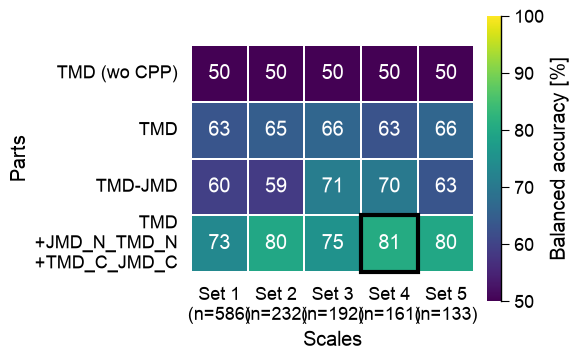

In [6]:
# Features from substrates vs unlabelled (df_sub_unl, labels_unl); benchmark on substrates vs the
# 14 known non-substrates (df_sub_nonsub, labels_nonsub) with the SVM + leave-one-out evaluator.
scale_sets = {"Set 1 (n=586)": scale_set1, "Set 2 (n=232)": scale_set2, "Set 3 (n=192)": scale_set3,
              "Set 4 (n=161)": scale_set4, "Set 5 (n=133)": scale_set5}
list_df_scales = [df_scales[ids] for ids in scale_sets.values()]
df_parts = sf.get_df_parts(df_seq=df_sub_unl, list_parts=["tmd", "jmd_n_tmd_n", "tmd_c_jmd_c"])

def bench_bacc(_df_feat, _list_parts):
    X = sf.feature_matrix(features=_df_feat["feature"],
                          df_parts=sf.get_df_parts(df_seq=df_sub_nonsub, list_parts=_list_parts), df_scales=df_scales)
    return balanced_acc(X, labels_sub_nonsub)

part_names = ["TMD (wo CPP)", "TMD", "TMD-JMD", "TMD\n+JMD_N_TMD_N\n+TMD_C_JMD_C"]
list_parts_cpp = [["tmd"], ["tmd_jmd"], ["tmd", "jmd_n_tmd_n", "tmd_c_jmd_c"]]   # the CPP part sets
heat = np.zeros((len(part_names), len(scale_sets)))

# Row 0 -- TMD without CPP: a single compositional segment (no Part-Split-Scale features).
split_kws_wo_cpp = sf.get_split_kws(split_types="Segment", n_split_min=1, n_split_max=1)
df_parts_cpp_tmd = sf.get_df_parts(df_seq=df_sub_unl, list_parts=["tmd"])
for j, df_scales_set in enumerate(list_df_scales):
    cpp = aa.CPP(df_parts=df_parts_cpp_tmd, df_scales=df_scales_set, split_kws=split_kws_wo_cpp)
    df_feat_wo = cpp.run(labels=labels_sub_unl, n_jobs=1, n_filter=150)
    heat[0, j] = bench_bacc(df_feat_wo, ["tmd"])

# Rows 1-3 -- the CPP part sets, swept in one CPPGrid call (parts x scales).
cppg = aa.CPPGrid(df_seq=df_sub_unl, labels=labels_sub_unl, random_state=42, n_jobs=8)
list_df_feat, df_params = cppg.run(params_parts={"list_parts": list_parts_cpp},
                                   params_scales=list_df_scales,
                                   params_cpp={"n_filter": 150})
for k, df_feat_k in enumerate(list_df_feat):
    pi, si = int(df_params.iloc[k]["list_parts"]), int(df_params.iloc[k]["df_scales"])
    heat[pi + 1, si] = bench_bacc(df_feat_k, list_parts_cpp[pi])

bi, bj = np.unravel_index(np.argmax(heat), heat.shape)
best_part, best_scale = part_names[bi], list(scale_sets)[bj]
best_parts = ["tmd"] if bi == 0 else list_parts_cpp[bi - 1]
best_split = split_kws_wo_cpp if bi == 0 else None
#print(f"Best: {best_part} x {best_scale}  ({heat[bi, bj]:.1f}% balanced accuracy)")

df_eval = pd.DataFrame(heat, index=part_names,
                       columns=[f"Set {i + 1}\n(n={len(s)})" for i, s in enumerate(scale_sets.values())])
# One call: annotated heatmap with the optimal (best-accuracy) cell boxed automatically.
aa.plot_settings(weight_bold=False, font_scale=0.8)
fig, ax = aa.AAPredPlot().eval(df_eval, kind="heatmap", vmin=50, vmax=100,
                               cbar_label="Balanced accuracy [%]")
ax.set_ylabel("Parts"); ax.set_xlabel("Scales")
plt.tight_layout()
plt.show()


## 5. Feature engineering: the global signature

Using the best configuration from the sweep, we run CPP, rank the features with a ``TreeModel``,
and read the **global** physicochemical signature three ways: the feature **ranking** (most
discriminative ``Part-Split-Scale`` features), the **feature map** (heatmap of the mean difference
per subcategory x position), and the positional **profile** (cumulative importance per residue).

signature: 150 features (study's exact set; part set 3)


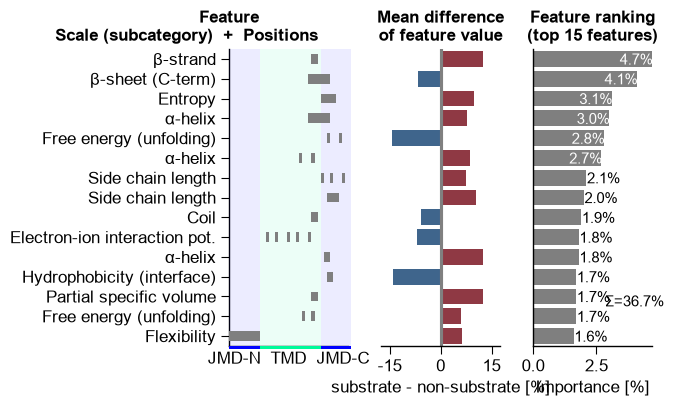

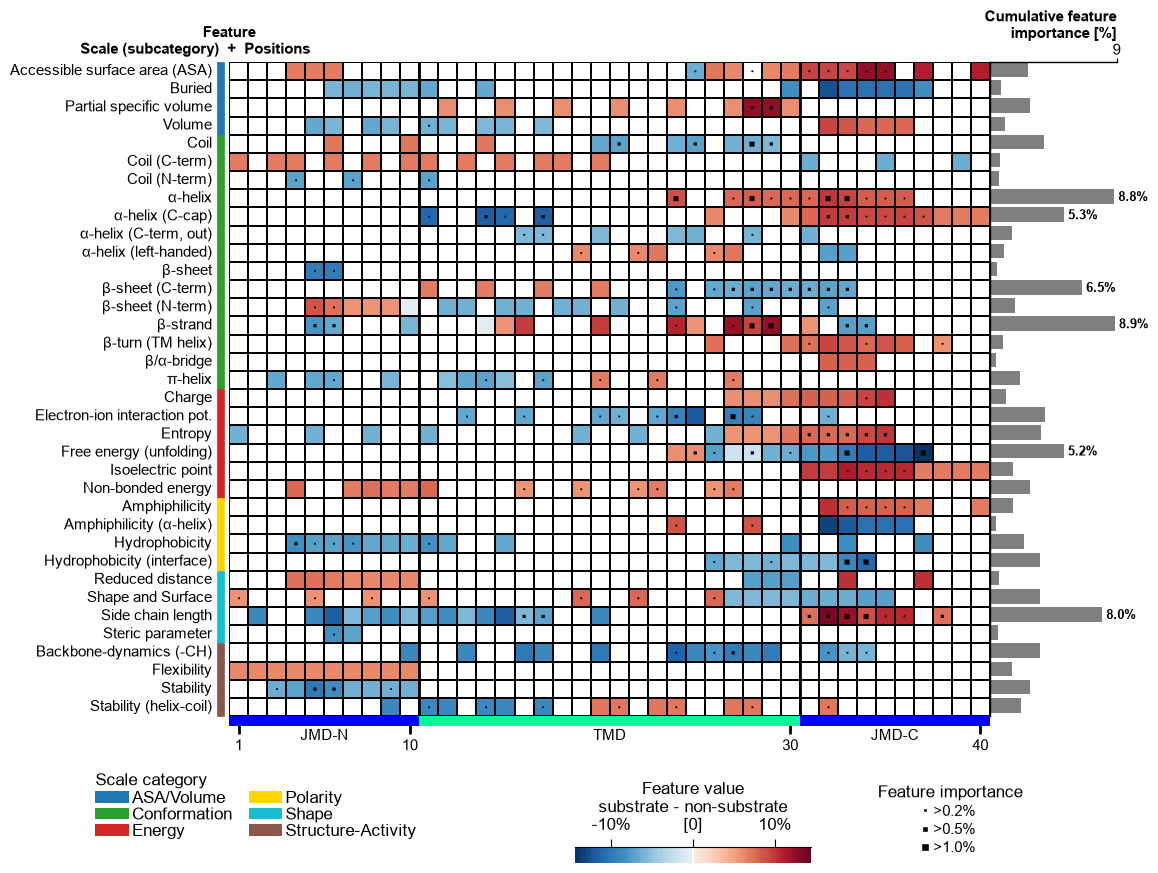

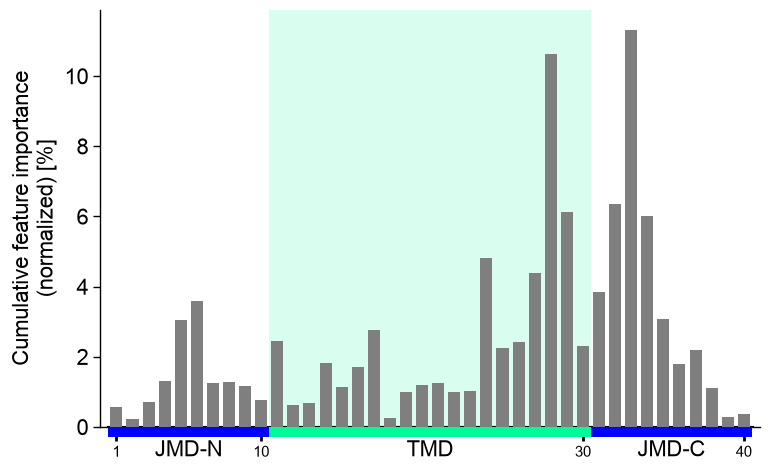

In [7]:
# Use the study's exact CPP signature (150 features, bundled with the package via load_features),
# generated for part set 3 (TMD, JMD_N_TMD_N, TMD_C_JMD_C) and scale set 5. The full scale table is
# reused downstream so every referenced scale is available for the feature matrices.
df_feat = aa.load_features(name="DOM_GSEC")
best_parts = ["tmd", "jmd_n_tmd_n", "tmd_c_jmd_c"]   # part set 3 (the study's choice)
df_scales_red = df_scales
print(f"signature: {df_feat.shape[0]} features (study's exact set; part set 3)")

cpp_plot = aa.CPPPlot()

# (1) Feature ranking.
aa.plot_settings(font_scale=0.8)
cpp_plot.ranking(df_feat=df_feat, n_top=15, name_test="substrate", name_ref="non-substrate")
plt.tight_layout()
plt.show()

# (2) Feature map as the heatmap alone (importance profile on top switched off).
aa.plot_settings(font_scale=0.6, weight_bold=False)
cpp_plot.feature_map(df_feat=df_feat, add_imp_bar_top=False, name_test="substrate", name_ref="non-substrate")
plt.tight_layout()
plt.show()

# (3) Profile: cumulative feature importance per residue position.
aa.plot_settings(font_scale=0.9)
cpp_plot.profile(df_feat=df_feat)
plt.tight_layout()
plt.show()

### Heatmap and profile, merged

Above, the heatmap and the importance profile are two separate plots. In the current AAanalysis
version they are **merged**: ``CPPPlot.feature_map`` draws the cumulative-importance **profile on
top** of the heatmap by default (``add_imp_bar_top=True``), so a single call gives both the
per-position importance profile and the position x subcategory map at once.

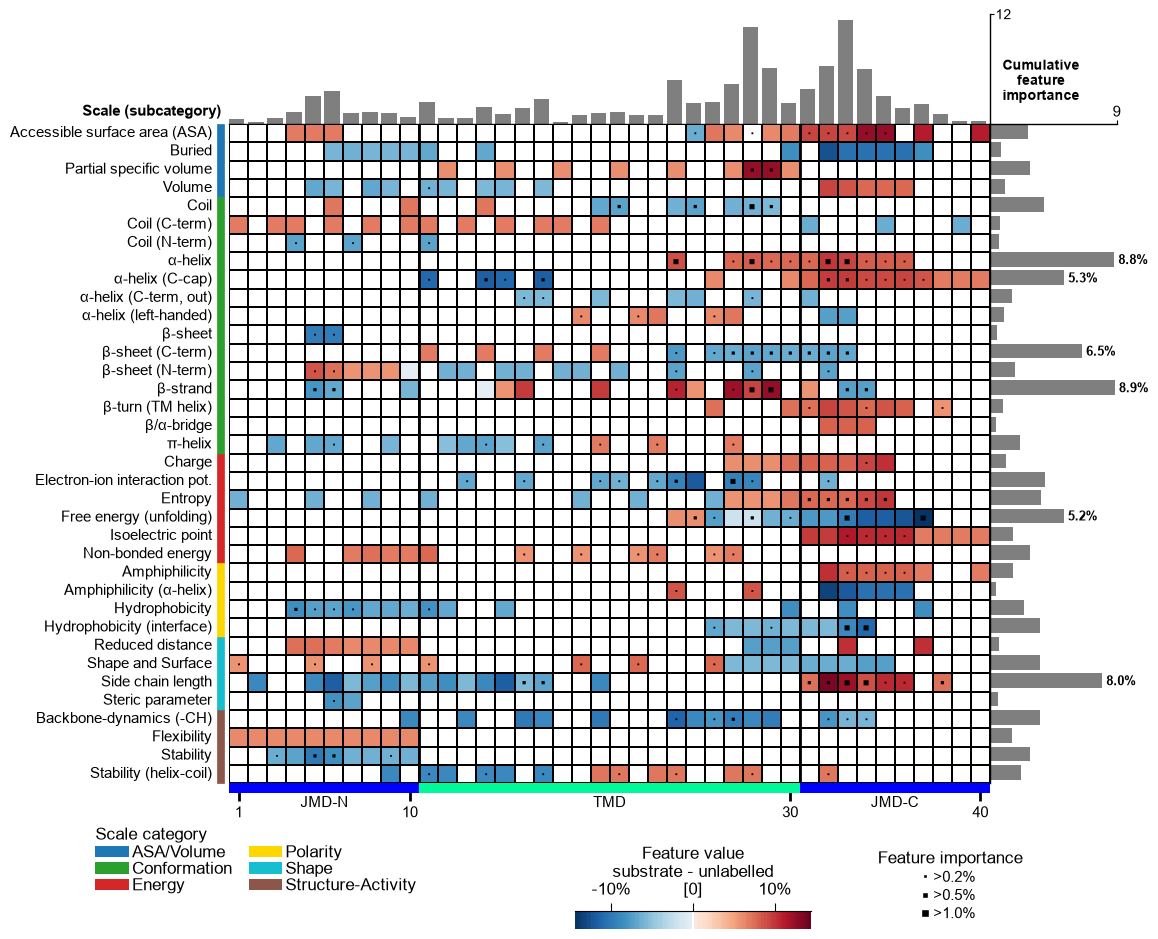

In [8]:
aa.plot_settings(font_scale=0.6, weight_bold=False)
aa.CPPPlot().feature_map(df_feat=df_feat, name_test="substrate", name_ref="unlabelled")  # profile on top (default)
plt.tight_layout()
plt.show()

## 6. dPULearn: mine reliable negatives

The 63 curated non-substrates were not all known upfront: only **14** were experimentally
confirmed; the other **49** were predicted by dPULearn from the unlabelled pool. The bundled
data still encodes that split — the curated negatives that never appear among the unlabelled
`DOM_GSEC_PU` "others" are exactly the 14 experimentally-known ones. **dPULearn** projects the
proteins into the CPP feature space (the best configuration above) and labels the unlabelled
points **most distant from the positives** as **reliable negatives**, deterministically,
extending the 14 to a balanced 63.

In [9]:
known_neg = sorted(set(_df_gsec.loc[y_dom == 0, "entry"]) - set(_df_gsec_pu.loc[y_pu == 2, "entry"]))
df_known = _df_gsec[_df_gsec["entry"].isin(known_neg)]
df_pos = _df_gsec_pu[_df_gsec_pu["label"] == 1]
df_others = _df_gsec_pu[_df_gsec_pu["label"] == 2]

def cpp_X(df):
    return sf.feature_matrix(features=df_feat["feature"],
                             df_parts=sf.get_df_parts(df_seq=df, list_parts=best_parts), df_scales=df_scales_red)
X_cpp_pos, X_cpp_known, X_cpp_oth = cpp_X(df_pos), cpp_X(df_known), cpp_X(df_others)

n_mine = 63 - len(known_neg)
X_pool = np.vstack([X_cpp_pos, X_cpp_oth])
y_pool = np.array([1] * len(X_cpp_pos) + [2] * len(X_cpp_oth))
dpul = aa.dPULearn(random_state=42)
dpul.fit(X=X_pool, labels=y_pool, n_unl_to_neg=n_mine)
mined_others = np.asarray(dpul.labels_)[len(X_cpp_pos):] == 0
print(f"positives: {len(df_pos)} | experimentally-known negatives: {len(known_neg)} "
      f"| dPULearn-mined reliable negatives: {int(mined_others.sum())}")

positives: 63 | experimentally-known negatives: 14 | dPULearn-mined reliable negatives: 49


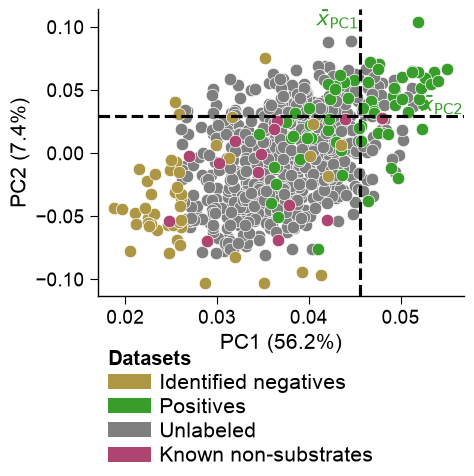

In [10]:
# Project the experimentally-known negatives into the fitted PC space and overlay them as a
# 4th group: dPULearn.project(X) + dPULearnPlot.pca(df_pu_add=...).
df_pu_known = dpul.project(X_cpp_known)
aa.plot_settings(font_scale=0.85)
aa.dPULearnPlot().pca(df_pu=dpul.df_pu_, labels=np.asarray(dpul.labels_),
                      df_pu_add=df_pu_known, names_add="Known non-substrates",
                      colors_add=COLOR_NONSUB)
plt.tight_layout()
plt.show()

The positives (green) cluster on one side of the CPP feature space; dPULearn picks
the unlabelled points (grey) farthest from them as **reliable negatives** (gold).

## 7. Sequence logo of the reliable negatives

What do the mined negatives look like? Their information logo, beside the substrates', shows
dPULearn selected coherent membrane proteins (not noise) — yet still with no single
distinguishing motif, reinforcing that the difference is physicochemical.

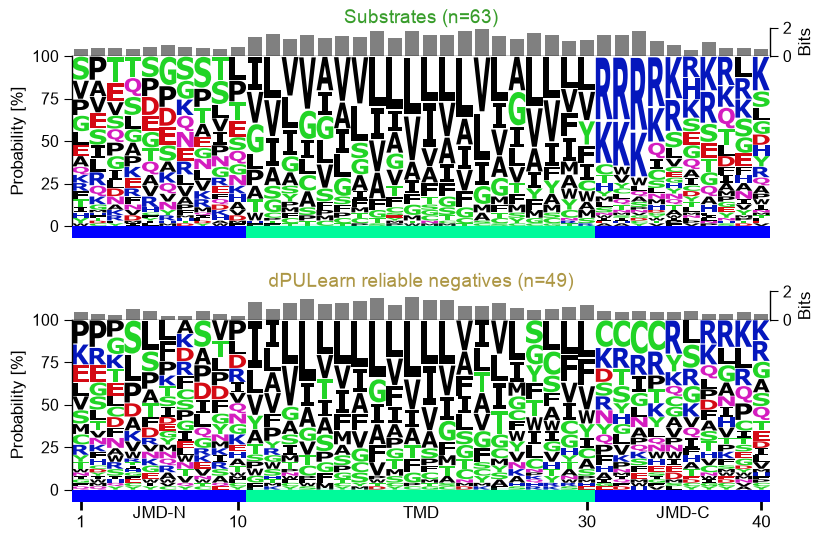

In [11]:
df_mined = df_others.iloc[np.where(mined_others)[0]].reset_index(drop=True)
df_parts_mined = sf.get_df_parts(df_seq=df_mined, list_parts=["jmd_n", "tmd", "jmd_c"],
                              jmd_n_len=JMD_LEN, jmd_c_len=JMD_LEN)

# Substrates (selected from the merged frame by label_test) beside all mined reliable negatives.
aa.plot_settings(font_scale=0.7)
aal_plot.multi_logo(
    list_aal_kws=[
        dict(df_parts=df_parts_merged, labels=labels, label_test=1, tmd_len=20, start_n=False),
        dict(df_parts=df_parts_mined, tmd_len=20, start_n=False),
    ],
    list_name_data=["Substrates (n=63)", "dPULearn reliable negatives (n=49)"],
    list_name_data_color=[COLOR_SUB, COLOR_REL_NONSUB],
    figsize_per_logo=(9, 3),
    info_bar_ylim=(0, 2),
)
plt.tight_layout()
plt.show()

## 8. Prediction evaluation

### Optimizing the feature and negative counts

How many CPP features and how many dPULearn negatives are enough? Sweep both and read
5-fold balanced accuracy as a heatmap (always 63 positives + the 14 known negatives,
extended by the top dPULearn-mined negatives).

In [12]:
feat_list = df_feat["feature"]
n_feats = [25, 50, 75, 100]
n_negs = [20, 35, 49, 63]
heat = np.zeros((len(n_feats), len(n_negs)))
for i, nf in enumerate(n_feats):
    feats = feat_list.iloc[:nf]
    Xp = sf.feature_matrix(features=feats, df_parts=sf.get_df_parts(df_seq=df_pos, list_parts=best_parts), df_scales=df_scales_red)
    Xk = sf.feature_matrix(features=feats, df_parts=sf.get_df_parts(df_seq=df_known, list_parts=best_parts), df_scales=df_scales_red)
    Xo = sf.feature_matrix(features=feats, df_parts=sf.get_df_parts(df_seq=df_others, list_parts=best_parts), df_scales=df_scales_red)
    d = aa.dPULearn(random_state=42)
    d.fit(X=np.vstack([Xp, Xo]), labels=np.array([1]*len(Xp) + [2]*len(Xo)), n_unl_to_neg=max(n_negs))
    order = np.where(np.asarray(d.labels_)[len(Xp):] == 0)[0]
    for j, nn in enumerate(n_negs):
        take = min(nn, len(order))
        X = np.vstack([Xp, Xk, Xo[order[:take]]])
        heat[i, j] = balanced_acc(X, [1]*len(Xp) + [0]*(len(Xk) + take))
print("best balanced accuracy: %.1f%%" % heat.max())

best balanced accuracy: 94.2%


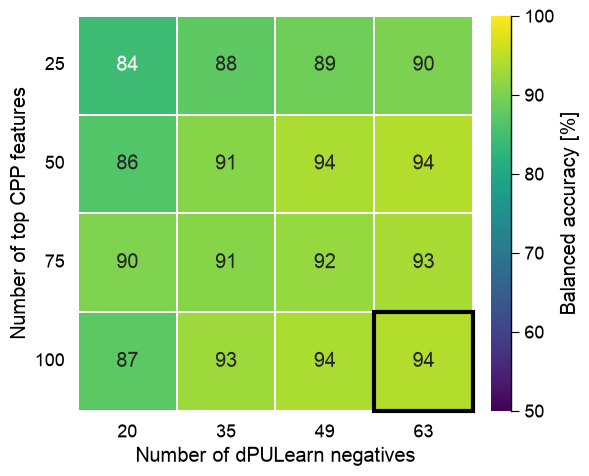

In [13]:
df_eval = pd.DataFrame(heat, index=n_feats, columns=n_negs)
# One call: the recurring "score grid -> heatmap -> box the best config" block.
aa.plot_settings(weight_bold=False, font_scale=0.8)
fig, ax = aa.AAPredPlot().eval(df_eval, kind="heatmap", vmin=50, vmax=100,
                               cbar_label="Balanced accuracy [%]")
ax.set_xlabel("Number of dPULearn negatives"); ax.set_ylabel("Number of top CPP features")
plt.tight_layout()
plt.show()

### Comparing against the baseline

Two axes, as in the study. Always train on the 63 positives; vary the **feature method**
(a scale-average baseline — each scale averaged over the whole sequence, no positional
splits — vs. the **CPP** signature) and the **data expansion** (14 known negatives only /
+49 random others / +49 dPULearn-mined reliable negatives). CPP beats the baseline at every
column, and dPULearn beats *no* and *random* expansion: it is *interpretable features and
reliable negatives*, not just more data, that reach the study's accuracy.

In [14]:
def scale_X(df):
    seqs = (df["jmd_n"] + df["tmd"] + df["jmd_c"]).to_list()
    return np.array([df_scales_red.loc[[a for a in s if a in df_scales_red.index]].mean(axis=0).values
                     for s in seqs])
X_sc_pos, X_sc_known, X_sc_oth = scale_X(df_pos), scale_X(df_known), scale_X(df_others)

def bench(X_pos, X_known, X_oth):
    none = balanced_acc(np.vstack([X_pos, X_known]), [1]*len(X_pos) + [0]*len(X_known))
    rnd = []
    for seed in range(3):
        pick = np.random.default_rng(seed).choice(len(X_oth), size=n_mine, replace=False)
        rnd.append(balanced_acc(np.vstack([X_pos, X_known, X_oth[pick]]),
                                [1]*len(X_pos) + [0]*(len(X_known) + n_mine)))
    dpu = balanced_acc(np.vstack([X_pos, X_known, X_oth[mined_others]]),
                       [1]*len(X_pos) + [0]*(len(X_known) + int(mined_others.sum())))
    return [none, float(np.mean(rnd)), dpu]

res_scale = bench(X_sc_pos, X_sc_known, X_sc_oth)
res_cpp = bench(X_cpp_pos, X_cpp_known, X_cpp_oth)
cols = ["No expansion\n(14 known)", "Random\nexpansion", "dPULearn\nexpansion"]
print("Scale-based :  " + "  ".join(f"{v:5.1f}%" for v in res_scale))
print("CPP         :  " + "  ".join(f"{v:5.1f}%" for v in res_cpp))

Scale-based :   50.0%   57.7%   75.4%
CPP         :   77.0%   80.7%   90.5%


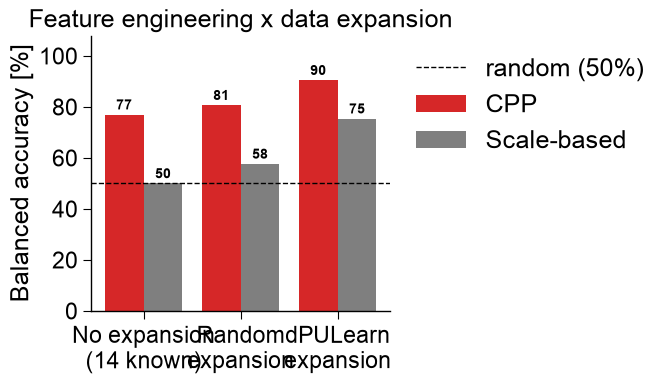

In [15]:
# One call: grouped comparison barplot with per-bar labels + a chance line.
df_bench = pd.DataFrame({"group": np.repeat(["Scale-based", "CPP"], len(cols)),
                         "condition": cols * 2,
                         "value": list(res_scale) + list(res_cpp)})
aa.plot_settings()
fig, ax = aa.AAPredPlot().eval(
    df_bench, kind="comparison", group="group", condition="condition", value="value",
    baseline=50, baseline_label="random (50%)", annotate=True, annotation_fmt="{:.0f}",
    group_order=["CPP", "Scale-based"], condition_order=cols,
    colors={"CPP": "tab:red", "Scale-based": "tab:gray"}, ylim=(0, 108),
    ylabel="Balanced accuracy [%]", title="Feature engineering x data expansion")
plt.tight_layout()
plt.show()

## 9. Explaining individual proteins with SHAP

CPP describes the *group*; **SHAP** explains *one protein*. We first compute a **prediction score**
for each protein: the out-of-fold substrate probability **averaged over four models** — random
forest, SVM, logistic regression and XGBoost — all trained on the **balanced set** (63 substrates
+ 63 non-substrates, including the dPULearn-mined negatives). The spread (±std) reflects model
agreement. We then fit a `ShapModel` on the same balanced set (**hard labels, no fuzzy labeling**)
and read out per-residue feature impact.

We look at the substrates **APP** (Alzheimer-relevant) and **N-cadherin (CDH2)**, and the
non-substrate **TMX3**. *(Notch — the canonical cancer-relevant substrate — is not in the bundled
``DOM_GSEC`` subset, so CDH2 stands in as the second substrate.)*

APP (P05067): P(substrate) = 95% +/- 6%
CDH2 (P19022): P(substrate) = 93% +/- 5%
TMX3 (Q96JJ7): P(substrate) = 2% +/- 2%


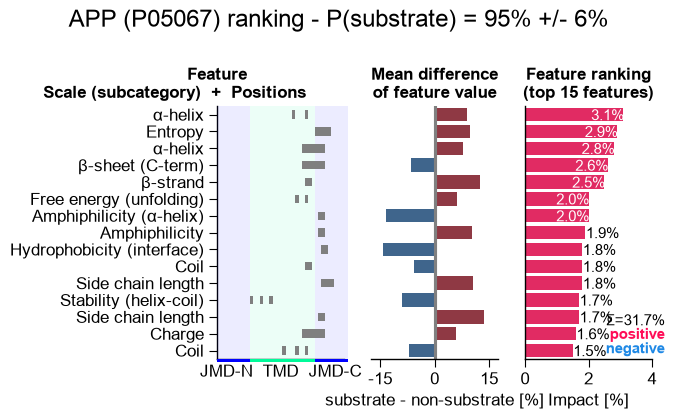

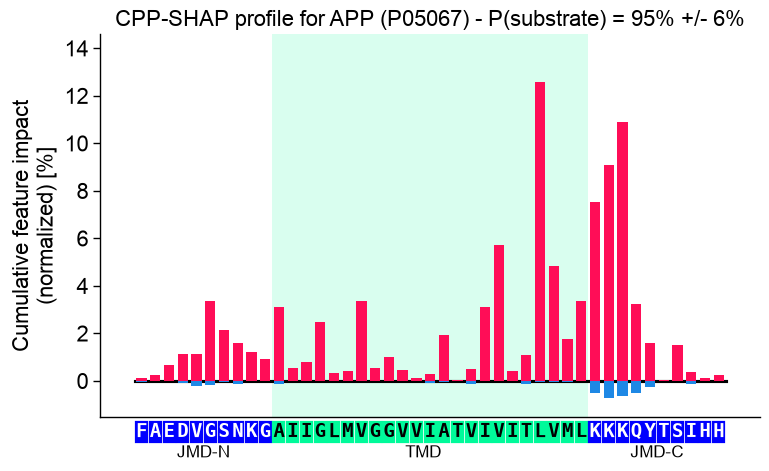

In [16]:
# Prediction score = out-of-fold substrate probability averaged over four models (random forest,
# SVM, logistic regression, XGBoost), all trained on the balanced set (63 substrates + 63
# non-substrates, incl. dPULearn negatives). The std reflects model agreement.
samples = {"APP": "P05067", "CDH2": "P19022", "TMX3": "Q96JJ7"}
df_parts_dom = sf.get_df_parts(df_seq=_df_gsec, list_parts=best_parts)
X_shap = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts_dom, df_scales=df_scales_red)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "RF": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": CalibratedClassifierCV(SVC(kernel="linear"), cv=5),
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, random_state=42, verbosity=0),
}
proba_all = np.vstack([cross_val_predict(m, X_shap, y_dom, cv=cv5, method="predict_proba")[:, 1]
                       for m in models.values()])
proba_mean, proba_std = proba_all.mean(axis=0), proba_all.std(axis=0)
positions = [int(np.where(_df_gsec["entry"].values == acc)[0][0]) for acc in samples.values()]
pred_score = {acc: float(proba_mean[pos]) for acc, pos in zip(samples.values(), positions)}
pred_std = {acc: float(proba_std[pos]) for acc, pos in zip(samples.values(), positions)}
for name, acc in samples.items():
    print(f"{name} ({acc}): P(substrate) = {pred_score[acc]:.0%} +/- {pred_std[acc]:.0%}")

# SHAP without fuzzy labeling: hard substrate/non-substrate labels.
sm = aa.ShapModel(random_state=42)
sm.fit(X_shap, labels=list(y_dom))
df_feat = sm.add_feat_impact(df_feat=df_feat, samples=positions, names=list(samples))

def _title(prefix, acc):
    return f"{prefix} - P(substrate) = {pred_score[acc]:.0%} +/- {pred_std[acc]:.0%}"

# APP: SHAP feature ranking and positional profile.
aa.plot_settings(font_scale=0.8)
aa.CPPPlot().ranking(df_feat=df_feat, shap_plot=True, col_imp="feat_impact_APP", n_top=15,
                     name_test="substrate", name_ref="non-substrate")
plt.suptitle(_title("APP (P05067) ranking", "P05067"))
plt.tight_layout()
plt.show()

seq_kws_app = sf.get_seq_kws(df_seq=_df_gsec, df_parts=df_parts_dom, sample="P05067")
aa.plot_settings(font_scale=0.9)
aa.CPPPlot().profile(df_feat=df_feat, shap_plot=True, col_imp="feat_impact_APP", **seq_kws_app)
plt.title(_title("CPP-SHAP profile for APP (P05067)", "P05067"))
plt.tight_layout()
plt.show()

### Prediction scores across all proteins

The same per-protein substrate scores can be summarized across the whole set in two convenience calls. A **confidence-banded histogram** (`predict_group(kind="hist", band=True)`) colors each bar by the confidence band it falls into, needing no class labels, and a **ranked bar chart** (`predict_group(kind="ranking")`) ranks the top candidates with model-agreement error bars.

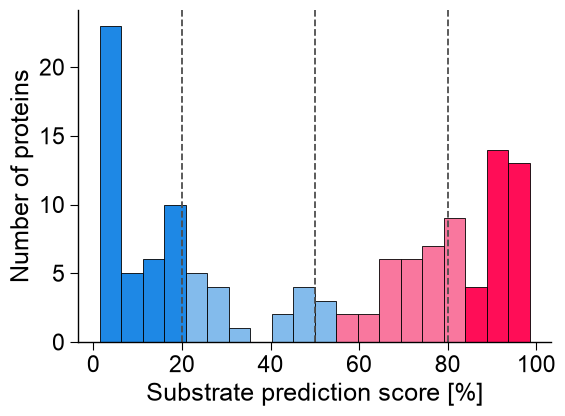

In [17]:
# Confidence-banded score histogram (no labels needed): bars colored by their band.
scores_pct = proba_mean * 100
aa.plot_settings()
aa.AAPredPlot().predict_group(scores_pct, kind="hist", band=True, thresholds=[20, 50, 80],
                              colors=["#1E88E5", "#83BBEC", "#F9779E", "#FF0D57"],
                              xlabel="Substrate prediction score [%]",
                              ylabel="Number of proteins")
plt.tight_layout()
plt.show()

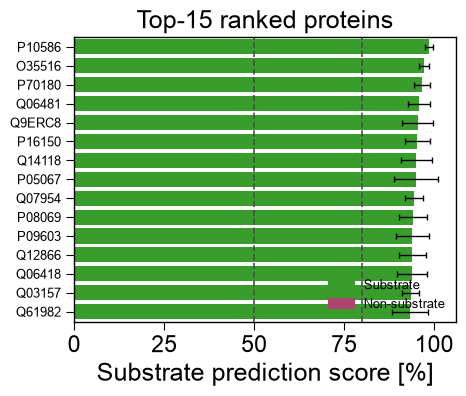

In [18]:
# Ranked candidates with model-agreement error bars, colored by class.
df_rank = pd.DataFrame({"entry": _df_gsec["entry"].to_numpy(),
                        "score": proba_mean * 100,
                        "std": proba_std * 100,
                        "group": np.where(y_dom == 1, "Substrate", "Non-substrate")})
aa.plot_settings()
aa.AAPredPlot().predict_group(df_rank, kind="ranking", col_name="entry", col_score="score",
                              col_std="std", col_group="group",
                              colors={"Substrate": COLOR_SUB, "Non-substrate": COLOR_NONSUB},
                              cutoffs=(50, 80), top_n=15,
                              xlabel="Substrate prediction score [%]",
                              title="Top-15 ranked proteins")
plt.tight_layout()
plt.show()

### CPP-SHAP feature map (newly added)

The per-sample **SHAP feature map** below is a **new addition** in AAanalysis — it is *not* part of
the original paper figures. It overlays a single protein's per-residue SHAP feature impact on the
CPP feature-map layout (scale subcategory x residue position), with the protein's **amino-acid
sequence** along the x-axis and its **prediction score** in the title. Shown for the substrates
APP and CDH2 and the non-substrate TMX3.

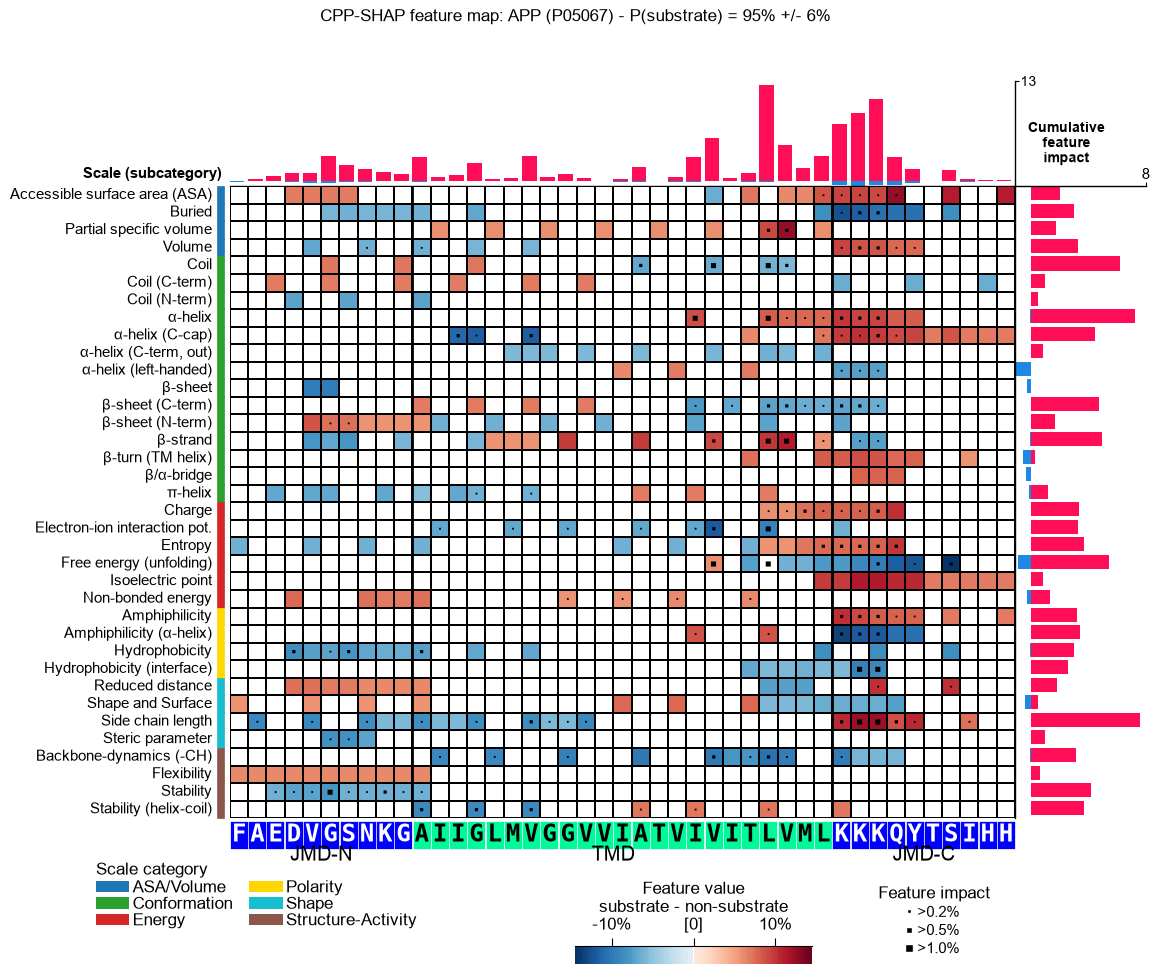

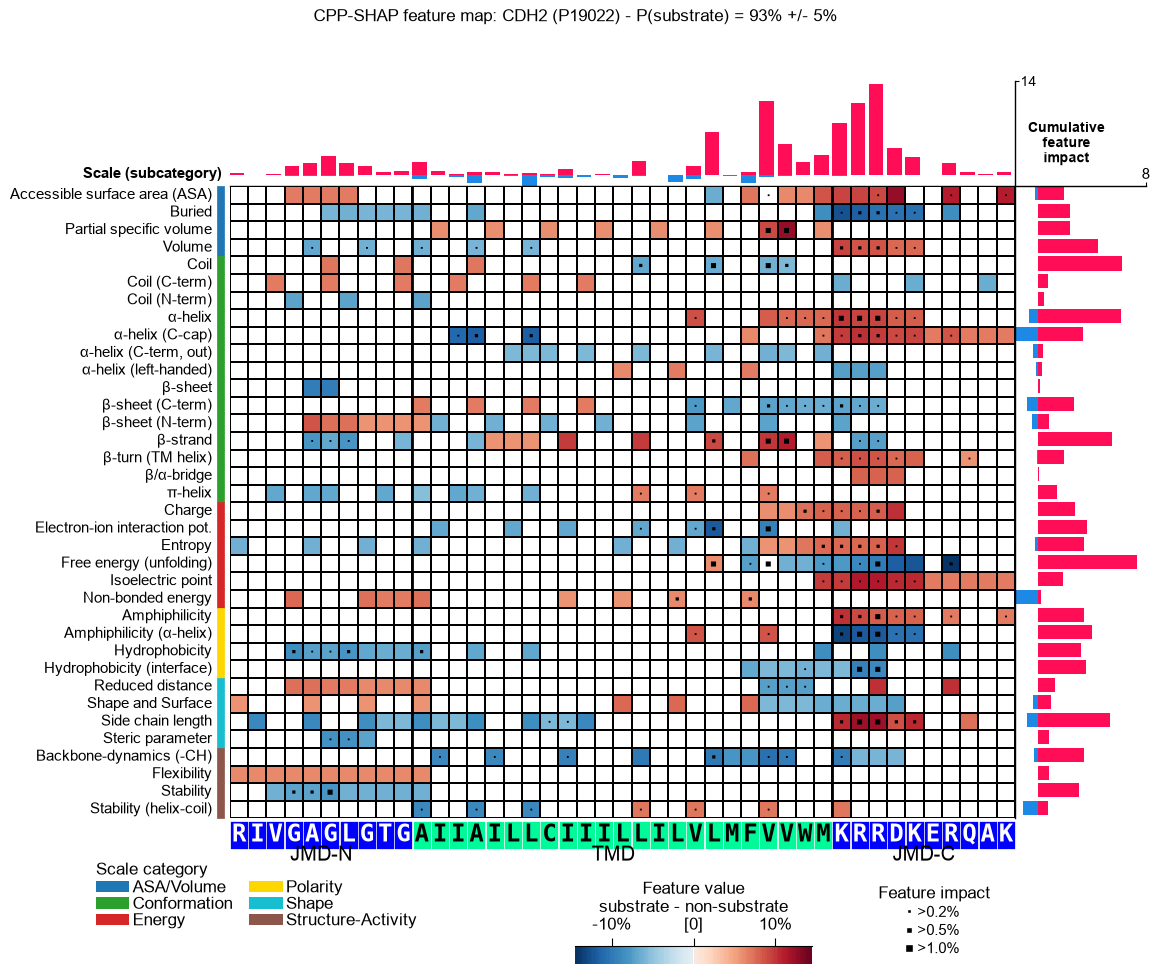

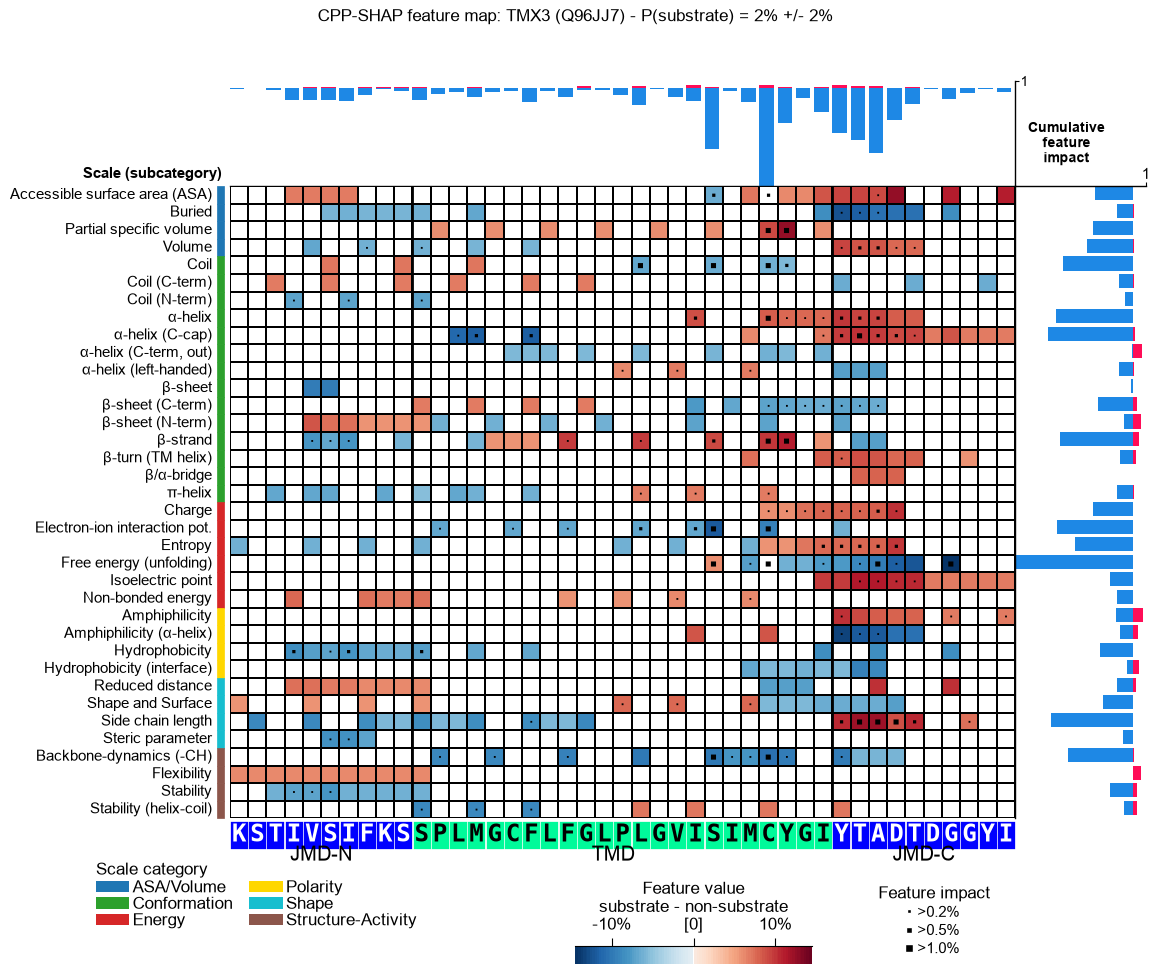

In [19]:
for name, acc in samples.items():
    seq_kws = sf.get_seq_kws(df_seq=_df_gsec, df_parts=df_parts_dom, sample=acc)
    aa.plot_settings(font_scale=0.6, weight_bold=False)
    fig, ax = aa.CPPPlot().feature_map(df_feat=df_feat, shap_plot=True, col_imp=f"feat_impact_{name}",
                                       name_test="substrate", name_ref="non-substrate", **seq_kws)
    fig.suptitle(_title(f"CPP-SHAP feature map: {name} ({acc})", acc), y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

The prediction scores track substrate status — high for the substrates **APP** and **CDH2**, near
zero for the non-substrate **TMX3** — and the per-residue SHAP impact peaks in the **cleavage
region** (C-terminal TMD into the JMD-C) for substrates: the single-residue interpretability behind
the "explainable AI" in the study's title.

## Summary

Showcased from bundled data the full arc of the study:

- **No motif** — the substrate, non-substrate and unlabelled information logos share one
  architecture and differ only subtly; the signal is physicochemical, not a letter pattern.
- **AAclust** builds five redundancy-reduced scale sets with 100% subcategory coverage
  (**586 -> 232 -> 192 -> 161 -> 133**).
- **Optimization** — CPP features are generated from the substrate-vs-unlabelled contrast and each
  part-set x scale-set configuration is scored on the honest task (substrate vs the 14
  experimentally-known non-substrates) with 5-fold CV via :class:`CPPGrid`. Without CPP the TMD is
  near chance; the best CPP configuration (TMD + membrane-boundary parts) reaches ~**73%**.
- **Feature engineering** — a `TreeModel` ranks the signature, shown as ranking, feature map and
  profile; in the current AAanalysis the heatmap and profile are merged (profile on top).
- **dPULearn** mines reliable negatives from the unlabelled pool to balance the data.
- **Prediction** — CPP beats a scale-average baseline, and dPULearn beats no-/random-expansion. The evaluation heatmaps (best cell boxed), the comparison bars, the confidence-banded score histogram, the ranked candidates and the four-group PU-PCA are each a single :class:`AAPredPlot` / :class:`dPULearnPlot` call.
- **SHAP** explains individual substrates (APP, CDH2) at single-residue resolution.

**Scale it up.** To approach the full study — the imbalanced proteome, multi-model
leave-one-out CV, and proteome-wide prediction — follow the **Protocols**: *P1 (CPP
signature)*, *P4 (prediction tasks)*, *P7-P8 (selection & prediction)*, and *P9-P10
(interpretability & validation)*.

   Breimann and Kamp *et al.* (2025), *Charting γ-secretase substrates by explainable AI*,
   [Nature Communications 16, 5428](https://www.nature.com/articles/s41467-025-60638-z).

## Appendix: the same analysis via the `aap` pipe

The main text uses the explicit building blocks on purpose: every step is visible and the **published** signature (`aa.load_features("DOM_GSEC")`) is reproduced exactly. The same arc also runs in a handful of high-level `aaanalysis.pipe` (`aap`) calls, each discovering/scoring **and** drawing its own figure, with the remaining views as one-line `aa` plot methods on the pipe outputs. The pipe **auto-discovers** the feature set (`search="fast"`), so its signature and numbers differ slightly from the published exact set: the point here is the few-lines workflow, not byte-reproduction.

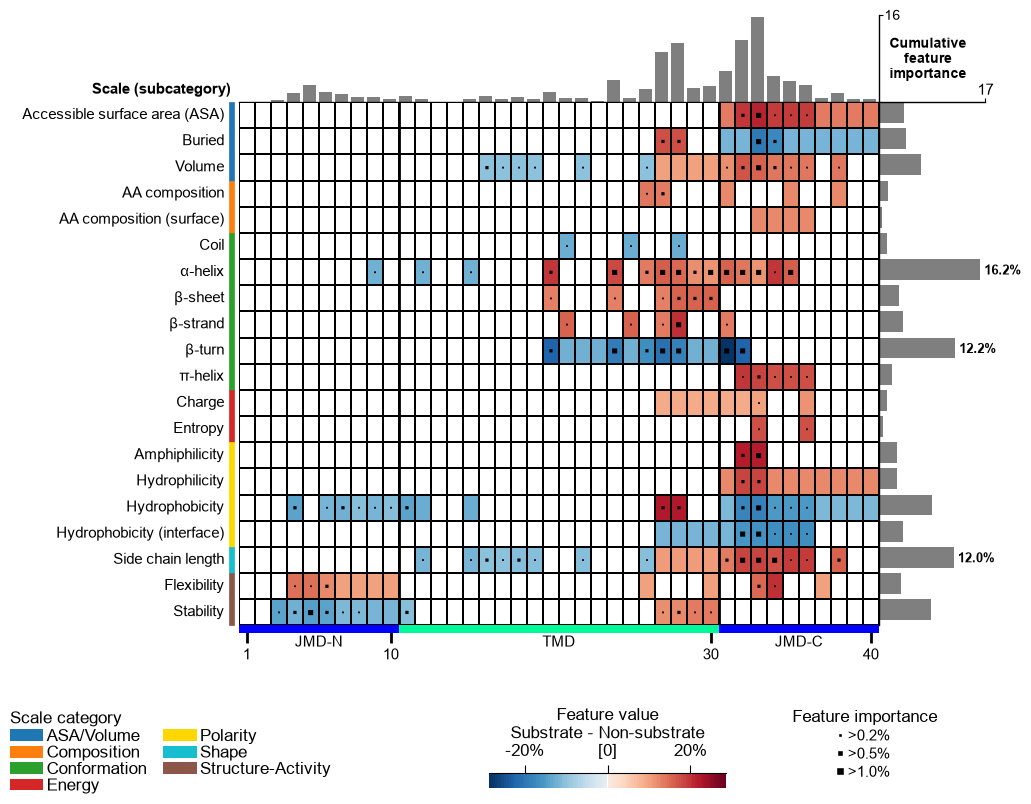

In [20]:
import aaanalysis.pipe as aap

# 1. Discover an interpretable feature set (optimisation + CPP + engineering) in one call.
df_feat_aap, ax_ev, df_eval_aap = aap.find_features(
    labels=list(y_dom), df_seq=_df_gsec, search="fast",
    name_test="Substrate", name_ref="Non-substrate", random_state=42)
plt.show()

DataFrame shape: (2, 17)


,feature_set,model,n_features,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,roc_auc_mean,roc_auc_std,is_shap_ready,is_best
1,features,rf,73,0.866026,0.037999,0.865538,0.038426,0.865430,0.032610,0.880303,0.065240,0.857692,0.057105,0.964793,0.025555,True,False
2,features,svm,73,0.898718,0.057069,0.897538,0.057429,0.906112,0.048286,0.858107,0.083014,0.969231,0.061538,0.968146,0.030508,False,True


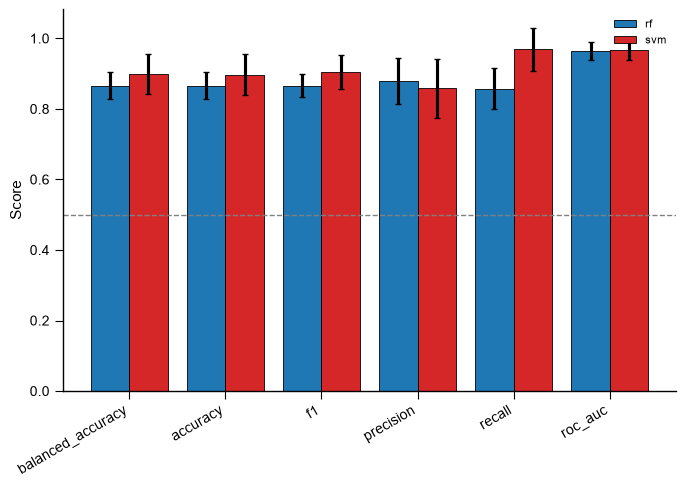

In [21]:
# 2. Benchmark models on the discovered features; plot=True draws the model comparison.
predictors, ax_cmp, df_cmp = aap.predict_samples(
    df_feat_aap, df_seq=_df_gsec, labels=list(y_dom),
    models=["rf", "svm"], baseline=0.5, random_state=42)
aa.display_df(df_cmp, n_rows=10, show_shape=True)
plt.tight_layout()
plt.show()

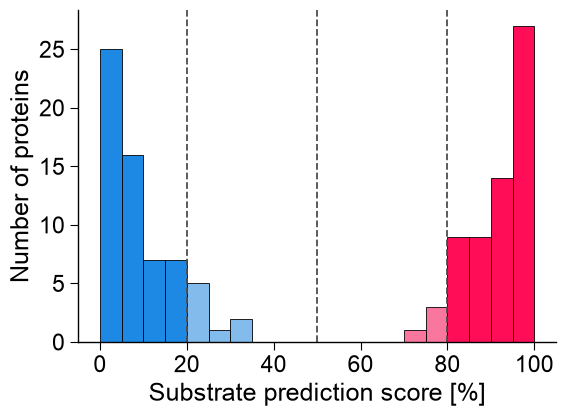

In [22]:
# 3. Per-protein scores from a fitted AAPred -> confidence-banded histogram (one aa call).
aap_model = aa.AAPred(df_feat=df_feat_aap, random_state=42)
X_aap = sf.feature_matrix(features=df_feat_aap, df_parts=sf.get_df_parts(df_seq=_df_gsec))
aap_model.fit(X_aap, list(y_dom))
score_aap = aap_model.predict(_df_gsec, level="sequence")["score"].to_numpy() * 100

aa.plot_settings()
aa.AAPredPlot().predict_group(score_aap, kind="hist", band=True, thresholds=[20, 50, 80],
                              colors=["#1E88E5", "#83BBEC", "#F9779E", "#FF0D57"],
                              xlabel="Substrate prediction score [%]", ylabel="Number of proteins")
plt.tight_layout()
plt.show()

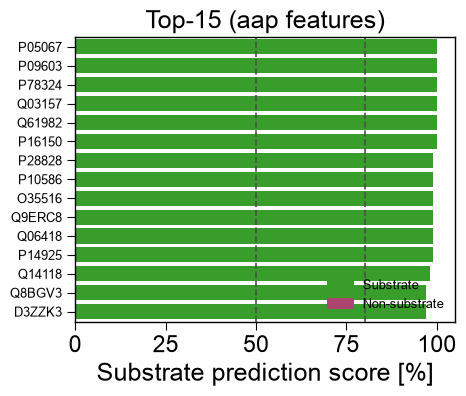

In [23]:
# ... and a ranked-candidates chart (a second aa call on the same scores).
df_rank_aap = pd.DataFrame({"entry": _df_gsec["entry"].to_numpy(), "score": score_aap,
                            "group": np.where(y_dom == 1, "Substrate", "Non-substrate")})
aa.plot_settings()
aa.AAPredPlot().predict_group(df_rank_aap, kind="ranking", col_name="entry", col_score="score",
                              col_group="group",
                              colors={"Substrate": COLOR_SUB, "Non-substrate": COLOR_NONSUB},
                              cutoffs=(50, 80), top_n=15,
                              xlabel="Substrate prediction score [%]", title="Top-15 (aap features)")
plt.tight_layout()
plt.show()

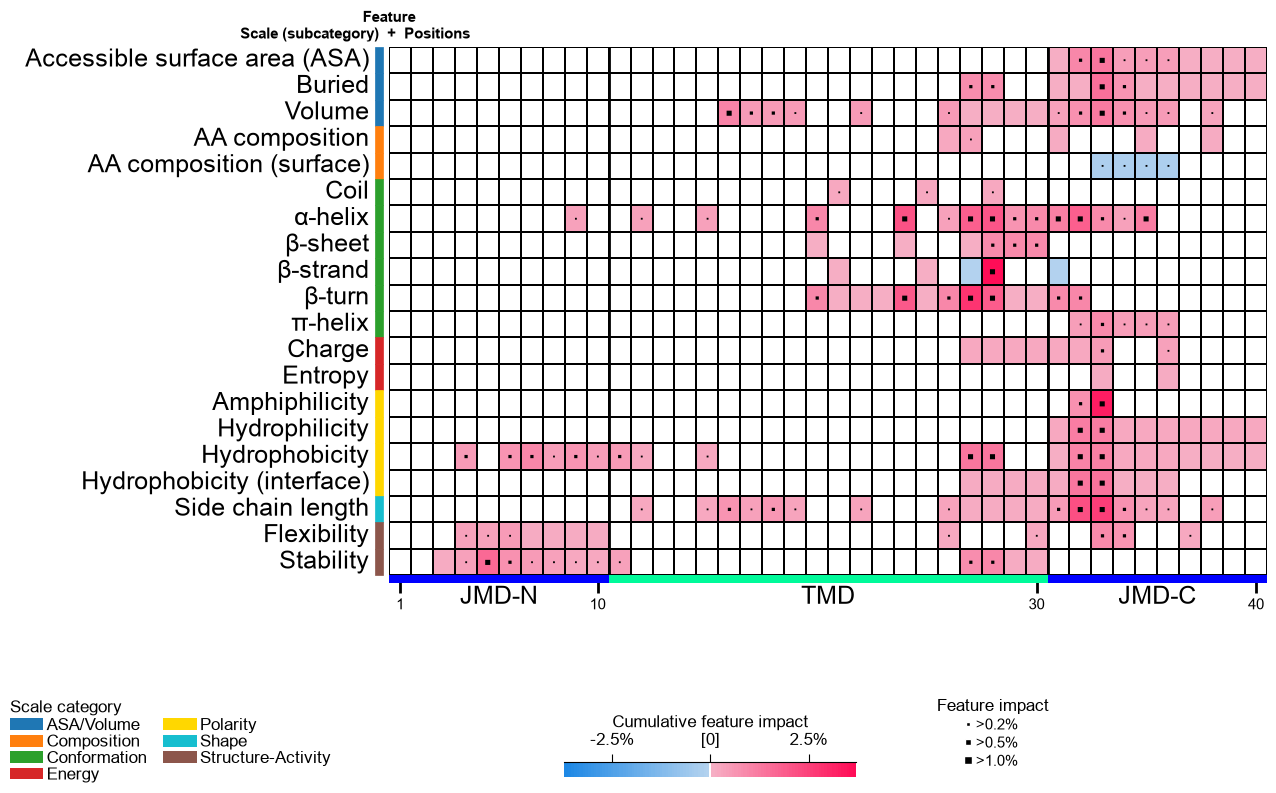

In [24]:
# 4. Explain a protein with a CPP-SHAP feature map in one call.
df_imp_aap, ax_shap, _ = aap.explain_features(
    df_feat=df_feat_aap, df_seq=_df_gsec, labels=list(y_dom), samples=["P05067"],
    name_test="Substrate", name_ref="Others", random_state=42)
plt.tight_layout()
plt.show()

### The whole result set in a few calls

- optimisation + feature engineering + eval grid -> `aap.find_features(...)`
- model benchmark + comparison figure -> `aap.predict_samples(..., plot=True)`
- per-protein score histogram + ranking -> `aa.AAPredPlot().predict_group(kind="hist"/"ranking")`
- per-protein CPP-SHAP feature map -> `aap.explain_features(...)`
- reliable-negative mining + four-group PU-PCA -> `aap.obtain_samples(reliable_negatives=True)` and `dPULearn.project()` + `aa.dPULearnPlot().pca(df_pu_add=...)` (main text section 6)

No hand-rolled `matplotlib` glue and no prototype helpers: every figure is a library call.